# regression problem

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import seaborn as sns

In [4]:
import matplotlib.pyplot as plt

In [5]:
dfhou=pd.read_csv(r"E:\My laptop docs\Desktop\ML_DataSets\housing.csv")

In [6]:
dfhou

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [7]:
dfhou.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# NaN's

In [8]:
dfhou.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [9]:
dfhou["total_bedrooms"] = dfhou["total_bedrooms"].fillna(dfhou["total_bedrooms"].median())

In [10]:
dfhou.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

# error detection

<Axes: >

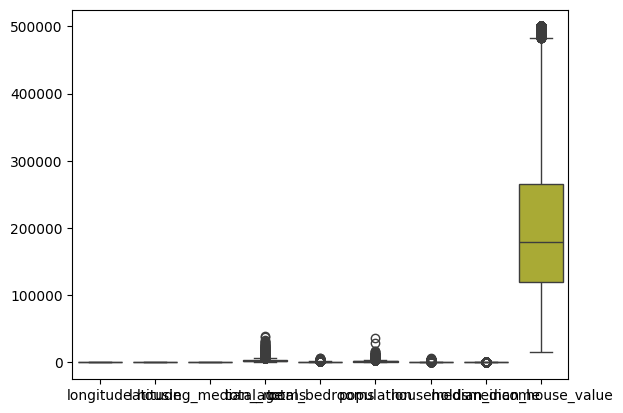

In [11]:
sns.boxplot(dfhou)

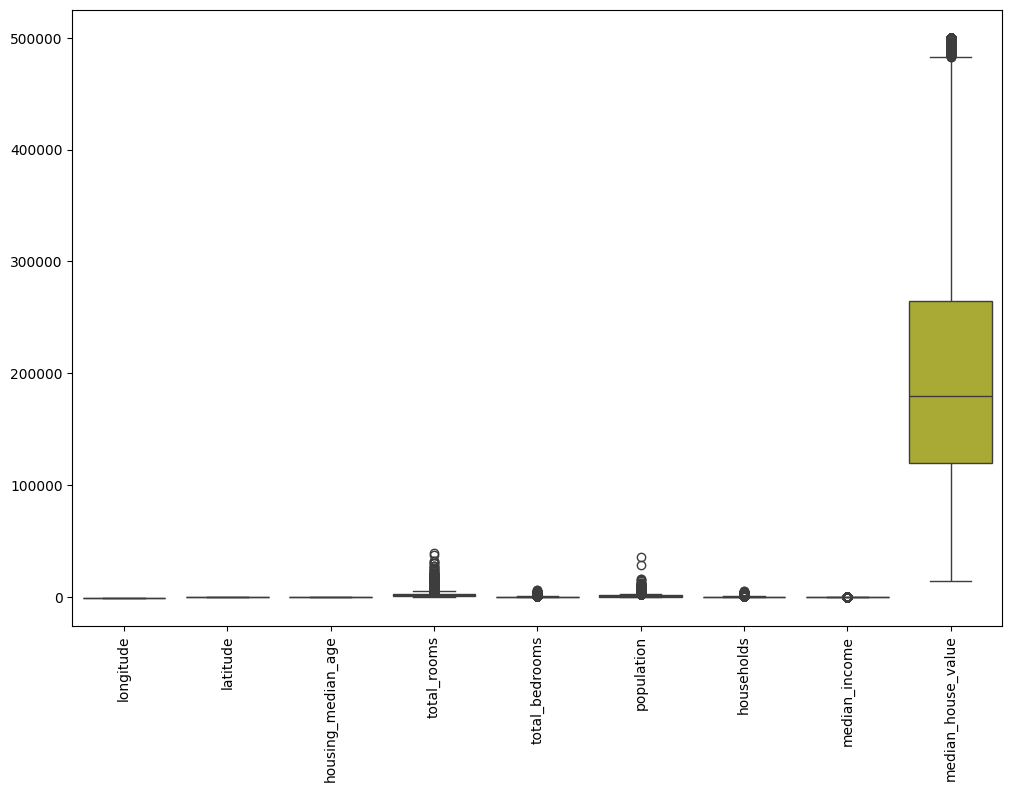

In [12]:
plt.figure(figsize=(12,8))
sns.boxplot(dfhou)
plt.xticks(rotation=90)
plt.show()

In [13]:
dfhou.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [14]:
cols=['total_rooms','total_bedrooms','population','households', 'median_income','ocean_proximity']

In [15]:
cols

['total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'ocean_proximity']

# capping

In [16]:
for c in dfhou.select_dtypes(include=['int64','float64']).columns:
    
    Q1 = dfhou[c].quantile(0.25)
    Q3 = dfhou[c].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    dfhou[c] = dfhou[c].apply(
        lambda x: lower if x < lower else upper if x > upper else x
    )

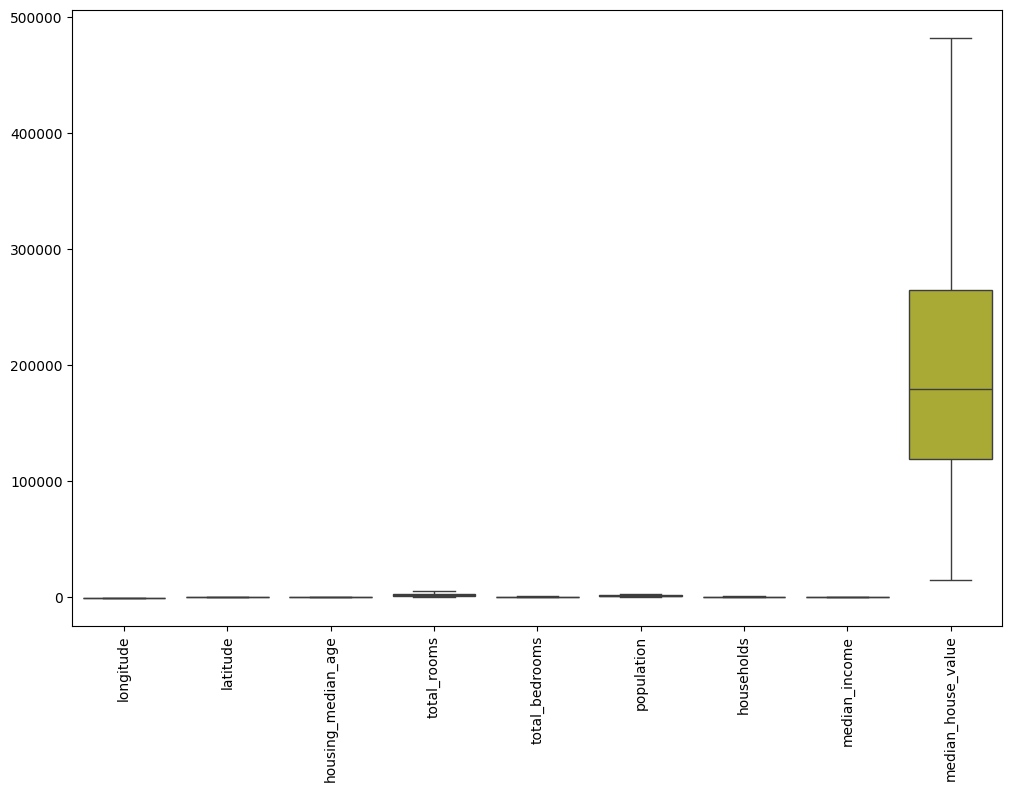

In [17]:
plt.figure(figsize=(12,8))
sns.boxplot(dfhou)
plt.xticks(rotation=90)
plt.show()

# encoding

In [18]:
import pandas as pd

dfhou = pd.get_dummies(dfhou, columns=["ocean_proximity"], dtype=int)

In [19]:
dfhou

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.000,129.0,322.0,126.0,8.013025,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,5698.375,1106.0,2401.0,1092.5,8.013025,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.000,190.0,496.0,177.0,7.257400,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.000,235.0,558.0,219.0,5.643100,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.000,280.0,565.0,259.0,3.846200,342200.0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.000,374.0,845.0,330.0,1.560300,78100.0,0,1,0,0,0
20636,-121.21,39.49,18.0,697.000,150.0,356.0,114.0,2.556800,77100.0,0,1,0,0,0
20637,-121.22,39.43,17.0,2254.000,485.0,1007.0,433.0,1.700000,92300.0,0,1,0,0,0
20638,-121.32,39.43,18.0,1860.000,409.0,741.0,349.0,1.867200,84700.0,0,1,0,0,0


# Data Separation

In [21]:
dfhou.drop("median_house_value",axis=1)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.000,129.0,322.0,126.0,8.013025,0,0,0,1,0
1,-122.22,37.86,21.0,5698.375,1106.0,2401.0,1092.5,8.013025,0,0,0,1,0
2,-122.24,37.85,52.0,1467.000,190.0,496.0,177.0,7.257400,0,0,0,1,0
3,-122.25,37.85,52.0,1274.000,235.0,558.0,219.0,5.643100,0,0,0,1,0
4,-122.25,37.85,52.0,1627.000,280.0,565.0,259.0,3.846200,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.000,374.0,845.0,330.0,1.560300,0,1,0,0,0
20636,-121.21,39.49,18.0,697.000,150.0,356.0,114.0,2.556800,0,1,0,0,0
20637,-121.22,39.43,17.0,2254.000,485.0,1007.0,433.0,1.700000,0,1,0,0,0
20638,-121.32,39.43,18.0,1860.000,409.0,741.0,349.0,1.867200,0,1,0,0,0


In [22]:
X=dfhou.drop("median_house_value",axis=1)

In [23]:
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.000,129.0,322.0,126.0,8.013025,0,0,0,1,0
1,-122.22,37.86,21.0,5698.375,1106.0,2401.0,1092.5,8.013025,0,0,0,1,0
2,-122.24,37.85,52.0,1467.000,190.0,496.0,177.0,7.257400,0,0,0,1,0
3,-122.25,37.85,52.0,1274.000,235.0,558.0,219.0,5.643100,0,0,0,1,0
4,-122.25,37.85,52.0,1627.000,280.0,565.0,259.0,3.846200,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.000,374.0,845.0,330.0,1.560300,0,1,0,0,0
20636,-121.21,39.49,18.0,697.000,150.0,356.0,114.0,2.556800,0,1,0,0,0
20637,-121.22,39.43,17.0,2254.000,485.0,1007.0,433.0,1.700000,0,1,0,0,0
20638,-121.32,39.43,18.0,1860.000,409.0,741.0,349.0,1.867200,0,1,0,0,0


In [24]:
y=dfhou["median_house_value"]

In [25]:
y

0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20640, dtype: float64

# Data Splitting

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=2)

In [28]:
X_train.shape

(16512, 13)

In [29]:
X_test.shape

(4128, 13)

In [30]:
y.value_counts()

median_house_value
482412.5    1071
137500.0     122
162500.0     117
112500.0     103
187500.0      93
            ... 
422900.0       1
349400.0       1
425800.0       1
200700.0       1
47000.0        1
Name: count, Length: 3779, dtype: int64

In [31]:
y_train.value_counts()

median_house_value
482412.5    843
137500.0     97
162500.0     88
112500.0     82
225000.0     75
           ... 
80500.0       1
430000.0      1
226600.0      1
309500.0      1
446700.0      1
Name: count, Length: 3637, dtype: int64

# Model Building

In [33]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
model.score(X_test,y_test)

0.6548062666072221

In [35]:
from sklearn.ensemble import RandomForestRegressor

In [36]:
rf= RandomForestRegressor()

In [37]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [38]:
rf.score(X_test,y_test)

0.8198052572057896

In [39]:
y_pred=rf.predict(X_test)

In [40]:
y_pred

array([277905., 165453.,  93513., ..., 163203.,  94399., 216628.],
      shape=(4128,))

# r2_score

In [41]:
from sklearn.metrics import r2_score

In [42]:
y_pred=rf.predict(X_test)

In [43]:
r2_score(y_test,y_pred)

0.8198052572057896

# Mean Squared Error

In [45]:
from sklearn.metrics import mean_squared_error

In [46]:
mean_squared_error(y_test,y_pred)

2332185285.3700123

In [47]:
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(48292.70426648328)

# Root Mean Squared Error

In [48]:
from sklearn.metrics import root_mean_squared_error

In [49]:
root_mean_squared_error(y_test,y_pred)

48292.70426648328

# Mean Absolute Error

In [50]:
from sklearn.metrics import mean_absolute_error

In [51]:
mean_absolute_error(y_test,y_pred)

31616.755067829457

In [52]:
print("Train score:", rf.score(X_train, y_train))

Train score: 0.9750524229848899


In [53]:
print("Test score:", rf.score(X_test, y_test))

Test score: 0.8198052572057896


# Cross Validation

In [55]:
from sklearn.model_selection import cross_val_score

In [56]:
from sklearn.ensemble import RandomForestRegressor

In [57]:
model = RandomForestRegressor()

In [58]:
model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [59]:
scores = cross_val_score(model, X, y, cv=5, n_jobs=-1)

In [60]:
scores

array([0.33596058, 0.5987567 , 0.70359443, 0.20809922, 0.63597674])

In [61]:
scores.mean()

np.float64(0.49647753371384606)

In [62]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# R2 score
from sklearn.metrics import r2_score
print("Test R2:", r2_score(y_test, y_pred))

# Cross Validation
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("CV scores:", scores)
print("Mean CV:", scores.mean())

Test R2: 0.7987800187028766
CV scores: [0.50404821 0.63348413 0.72278329 0.45006642 0.68261009]
Mean CV: 0.5985984269223723


{'whiskers': [<matplotlib.lines.Line2D at 0x18103e2f230>,
 'caps': [<matplotlib.lines.Line2D at 0x18103e2f4d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x18103e2f0e0>],
 'medians': [<matplotlib.lines.Line2D at 0x18103e2f770>],
 'fliers': [<matplotlib.lines.Line2D at 0x18103e2f8c0>],
 'means': []}

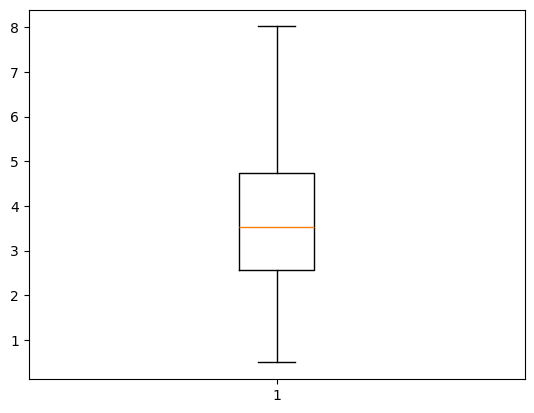

In [63]:
import seaborn as sns

plt.boxplot(x=dfhou['median_income'])

In [64]:
import numpy as np

dfhou['median_income'] = np.log1p(dfhou['median_income'])
dfhou['total_rooms'] = np.log1p(dfhou['total_rooms'])

In [65]:
dfhou

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,6.781058,129.0,322.0,126.0,2.198671,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,8.648112,1106.0,2401.0,1092.5,2.198671,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,7.291656,190.0,496.0,177.0,2.111110,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,7.150701,235.0,558.0,219.0,1.893579,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,7.395108,280.0,565.0,259.0,1.578195,342200.0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,7.418181,374.0,845.0,330.0,0.940124,78100.0,0,1,0,0,0
20636,-121.21,39.49,18.0,6.548219,150.0,356.0,114.0,1.268861,77100.0,0,1,0,0,0
20637,-121.22,39.43,17.0,7.720905,485.0,1007.0,433.0,0.993252,92300.0,0,1,0,0,0
20638,-121.32,39.43,18.0,7.528869,409.0,741.0,349.0,1.053336,84700.0,0,1,0,0,0


In [66]:
dfhou.columns = dfhou.columns.str.replace('[', '', regex=False)
dfhou.columns = dfhou.columns.str.replace(']', '', regex=False)
dfhou.columns = dfhou.columns.str.replace('<', '', regex=False)
dfhou.columns = dfhou.columns.str.replace('>', '', regex=False)
dfhou.columns = dfhou.columns.str.replace(' ', '_')

In [67]:
import re

dfhou.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in dfhou.columns]

In [68]:
print(dfhou.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity_1H_OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR_BAY', 'ocean_proximity_NEAR_OCEAN']


In [69]:
X = dfhou.drop('median_house_value', axis=1)
y = dfhou['median_house_value']

In [70]:
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_1H_OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR_BAY,ocean_proximity_NEAR_OCEAN
0,-122.23,37.88,41.0,6.781058,129.0,322.0,126.0,2.198671,0,0,0,1,0
1,-122.22,37.86,21.0,8.648112,1106.0,2401.0,1092.5,2.198671,0,0,0,1,0
2,-122.24,37.85,52.0,7.291656,190.0,496.0,177.0,2.111110,0,0,0,1,0
3,-122.25,37.85,52.0,7.150701,235.0,558.0,219.0,1.893579,0,0,0,1,0
4,-122.25,37.85,52.0,7.395108,280.0,565.0,259.0,1.578195,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,7.418181,374.0,845.0,330.0,0.940124,0,1,0,0,0
20636,-121.21,39.49,18.0,6.548219,150.0,356.0,114.0,1.268861,0,1,0,0,0
20637,-121.22,39.43,17.0,7.720905,485.0,1007.0,433.0,0.993252,0,1,0,0,0
20638,-121.32,39.43,18.0,7.528869,409.0,741.0,349.0,1.053336,0,1,0,0,0


In [71]:
y

0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20640, dtype: float64

In [72]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [73]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Model
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# 4. Train
model.fit(X_train, y_train)

# 5. Predict
y_pred = model.predict(X_test)

# 6. R2 score
print("Test R2:", r2_score(y_test, y_pred))

# 7. Cross Validation
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("CV scores:", scores)
print("Mean CV:", scores.mean())

Test R2: 0.8044224702353941
CV scores: [0.56632165 0.62973452 0.72542745 0.58169815 0.69360173]
Mean CV: 0.6393566997645598


In [74]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

params = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9]
}

xgb = XGBRegressor(random_state=42)

search = RandomizedSearchCV(xgb, params, cv=3, scoring='r2')
search.fit(X_train, y_train)

print(search.best_params_)

{'subsample': 0.9, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1}


In [75]:
search.best_score_

np.float64(0.8341997669259266)

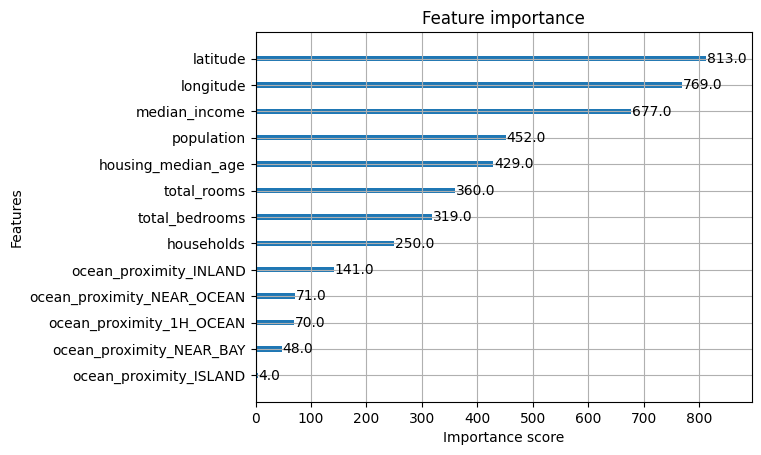

In [76]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model)
plt.show()

In [77]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 33999.28196160368
RMSE: 49727.22109815392


In [78]:
import joblib

joblib.dump(model, 'house_price_model.pkl')

['house_price_model.pkl']